In [1]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
#from netmap.downstream import final_downstream
from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
#from netmap.downstream.final_downstream import *
from netmap.downstream.plotting import *

from netmap.downstream.regulon import *
import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *


import scipy.sparse as scs


import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

import yaml


def save_clustering_score_to_yaml(analysis_output_dir, score):
    data = {'clustering_score': float(score) }
    with open(op.join(analysis_output_dir, 'clustering_score.yaml'), 'w') as file:
        yaml.dump(data, file, default_flow_style=False)

In [2]:
collectri = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/input_network/collectri.tsv', sep = '\t')
adata_raw = sc.read_h5ad(f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/10x-rep2-kallisto-cellbender/10x-rep2-kallisto-cellbender.h5ad')
experiment_name = '10x-rep2-kallisto-cellbender-X'
output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/{experiment_name}"
# This is where the GRN files are stored.
output_dir_grn = Path(op.join(output_dir, "grn"))
var = pd.read_csv(op.join(output_dir, f'{experiment_name}_var.tsv'))
obs = pd.read_csv(op.join(output_dir, f'{experiment_name}_obs.tsv'))
grn_adata = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)


FileNotFoundError: [Errno 2] No such file or directory: '/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/10x-rep2-kallisto-cellbender-X/10x-rep2-kallisto-cellbender-X_var.tsv'

In [ ]:
grn_adata.obs['celltype_semi_manual'] = adata_raw.obs['celltype_semi_manual'].values

In [ ]:
analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"

In [ ]:
os.makedirs(analysis_output_dir, exist_ok=True)

In [ ]:
adata_raw.obs['celltype_semi_manual'].value_counts()

celltype_semi_manual
cd14+_monocytes    4196
cd14-_monocytes    1023
cd4+_tcells         988
nk_cells            614
cd8+_tcells         285
DC                  214
pDC                 151
b_cells             139
Name: count, dtype: int64

In [ ]:
grn_adata = retrieve_top_edges(grn_adata, output_dir_grn, percentage=0.1 )

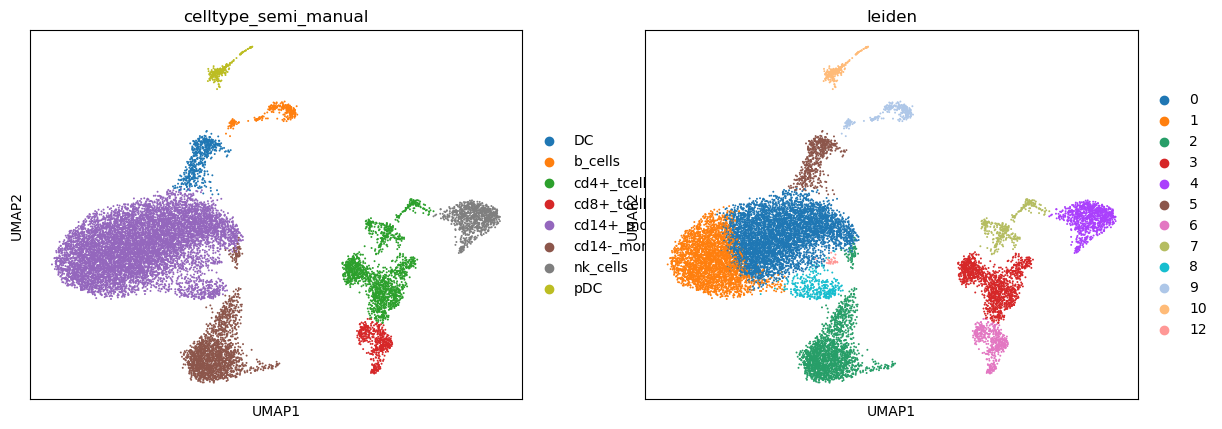

In [ ]:
with plt.rc_context(): 
    sc.pl.umap(adata_raw, color = ['celltype_semi_manual', 'leiden'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'gex_clustering_annotation_umap.pdf'), bbox_inches="tight")



In [ ]:
plt.show()

In [ ]:
grn_adata.var = grn_adata.var.set_index('index')



In [ ]:
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)


In [ ]:
sc.tl.tsne(grn_adata)

In [ ]:
sc.tl.leiden(grn_adata, resolution=0.29)

In [ ]:
with plt.rc_context(): 
    sc.pl.tsne(grn_adata, color = ['leiden', 'celltype_semi_manual'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'grn_clustering_comparison_tsne.pdf'), bbox_inches="tight")

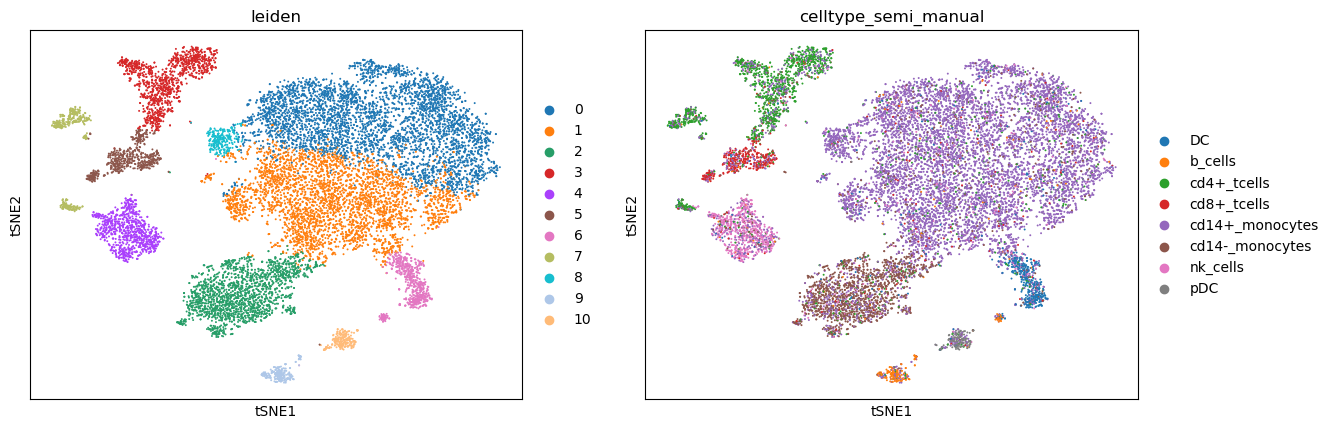

In [ ]:
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import min_weight_full_bipartite_matching
from sklearn.metrics.cluster import contingency_matrix

def unify_group_labelling(adata, grn_adata, col_adata, col_grn_adata, return_mapping=True):
    """
    Matches overclustered grn_adata to adata using Maximum Weight Bipartite Matching.
    This ensures every GRN cluster is assigned the 'best' possible reference 
    label while maximizing the global sum of cell overlaps.
    """
    # 1. Compute Contingency Matrix
    # Rows = adata (Ref), Cols = grn_adata (Target)
    cm = contingency_matrix(adata.obs[col_adata], grn_adata.obs[col_grn_adata])
    
    names_ad = np.unique(adata.obs[col_adata])
    names_grn = np.unique(grn_adata.obs[col_grn_adata])
    
    # 2. Maximum Weight Matching
    # SciPy's bipartite matching finds the MINIMUM weight. 
    # To find the MAXIMUM weight, we subtract the matrix from its maximum value.
    # Note: This handles the N > M case (overclustering) by ensuring 
    # each column (GRN cluster) finds its best match in the rows (Ref).
    
    # We transpose because we want a match for every column (GRN cluster)
    # cm.T shape: (n_grn_clusters, n_ref_clusters)
    cost_matrix = cm.max() - cm.T 
    
    # row_ind will correspond to names_grn indices
    # col_ind will correspond to names_ad indices
    # 'min_weight_full_bipartite_matching' will match all nodes of the smaller set.
    # Since we want a mapping for ALL GRN clusters, we use a greedy maximum 
    # weight assignment per cluster.
    
    reverse_mapping = {}
    total_matched_cells = 0
    
    # Efficiently find the max for each GRN cluster
    best_ref_indices = np.argmax(cm, axis=0)
    
    for grn_idx, ref_idx in enumerate(best_ref_indices):
        grn_label = names_grn[grn_idx]
        ref_label = names_ad[ref_idx]
        reverse_mapping[grn_label] = ref_label
        total_matched_cells += cm[ref_idx, grn_idx]

    # 3. Apply Mapping
    col_grn_remapped = f"{col_grn_adata}_remap"
    grn_adata.obs[col_grn_remapped] = grn_adata.obs[col_grn_adata].map(reverse_mapping)
    grn_adata.obs[col_grn_remapped] = pd.Categorical(grn_adata.obs[col_grn_remapped])

    score = total_matched_cells / grn_adata.n_obs
    
    if return_mapping:
        return score, reverse_mapping
    return score

In [ ]:
print("\nClustering Score Evaluation")

score, maping = unify_group_labelling(  adata_raw,grn_adata, 'celltype_semi_manual', 'leiden', True)
print(score)
save_clustering_score_to_yaml(analysis_output_dir, score)


Clustering Score Evaluation
0.8060932614913856


In [ ]:
maping

{'0': 'cd14+_monocytes',
 '1': 'cd14+_monocytes',
 '10': 'pDC',
 '2': 'cd14-_monocytes',
 '3': 'cd4+_tcells',
 '4': 'nk_cells',
 '5': 'cd8+_tcells',
 '6': 'DC',
 '7': 'cd4+_tcells',
 '8': 'cd14+_monocytes',
 '9': 'b_cells'}

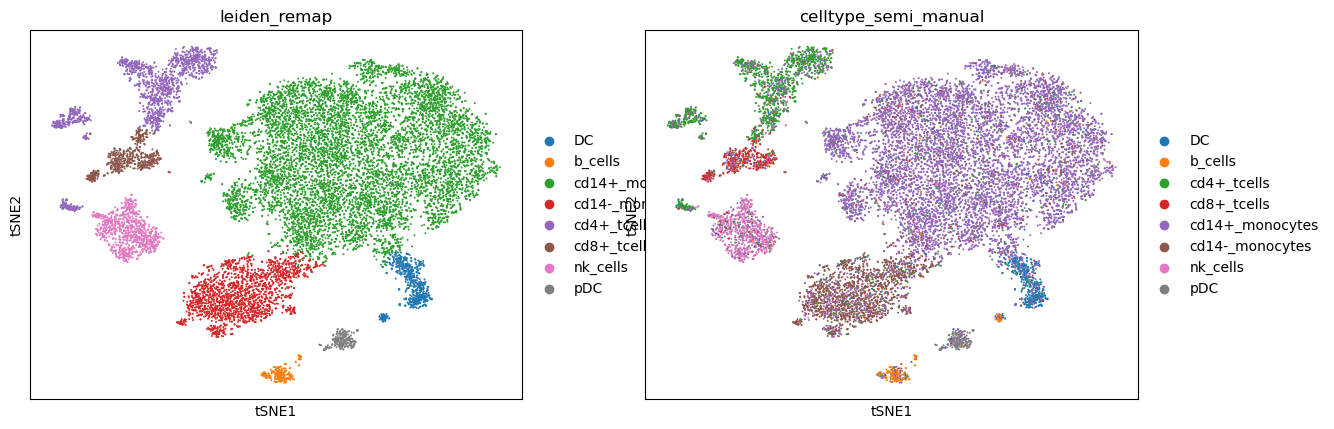

In [ ]:
sc.pl.tsne(grn_adata, color = ['leiden_remap', 'celltype_semi_manual'])


In [ ]:
adata_raw.obs['celltype_remapped'] = grn_adata.obs['leiden_remap'].values


In [ ]:
grn_adata2 = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)
grn_adata2.var = grn_adata2.var.set_index('index')

In [ ]:
grn_adata2.obs = grn_adata.obs

In [ ]:
add_neighbourhood_expression_mask(adata_raw, grn_adata2, strict=False, layer = 'counts' )
grn_adata2 = add_cluster_based_candidate_edges(grn_adata2, threshold=0.5)


In [ ]:
index_list = np.where(grn_adata2.var['candidate_edge'])[0]
grn_adata3 = retrieve_edges_by_index(grn_adata2, output_dir_grn, index_list)

In [ ]:
grn_adata3.obs = grn_adata2.obs
grn_adata3.obsm['X_pca'] = grn_adata.obsm['X_pca']
grn_adata3.obsm['X_umap'] = grn_adata.obsm['X_umap']

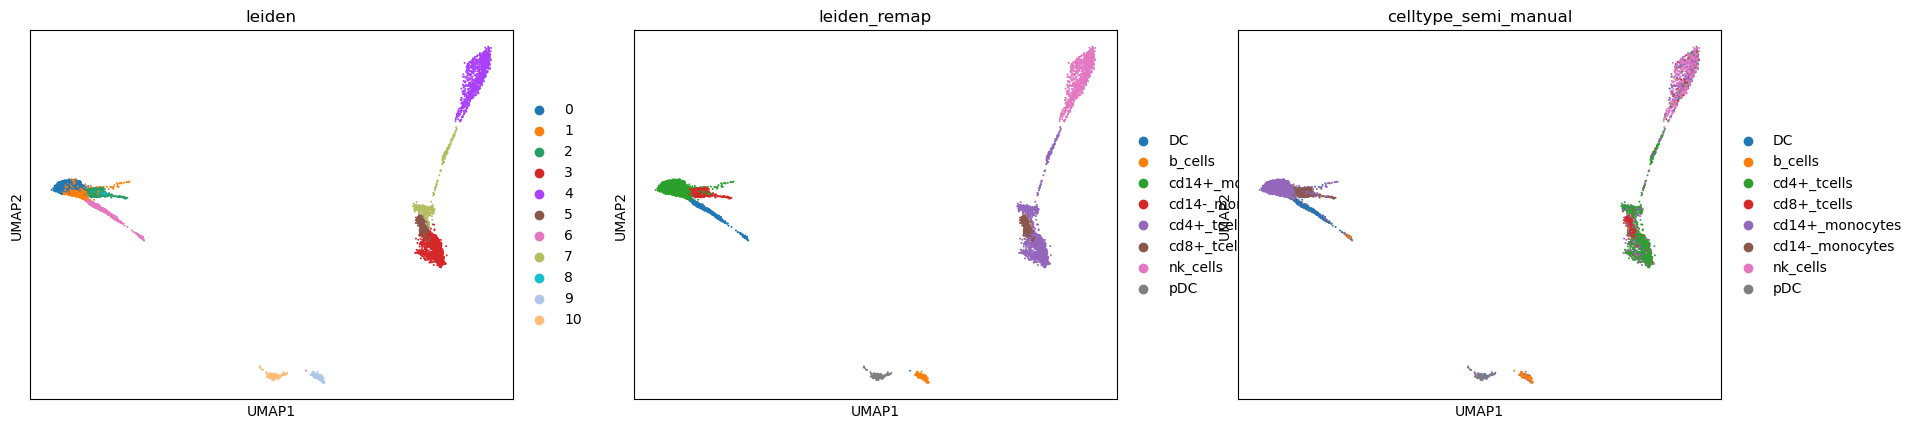

In [ ]:
sc.pl.umap(grn_adata3, color = ['leiden', 'leiden_remap', 'celltype_semi_manual'])

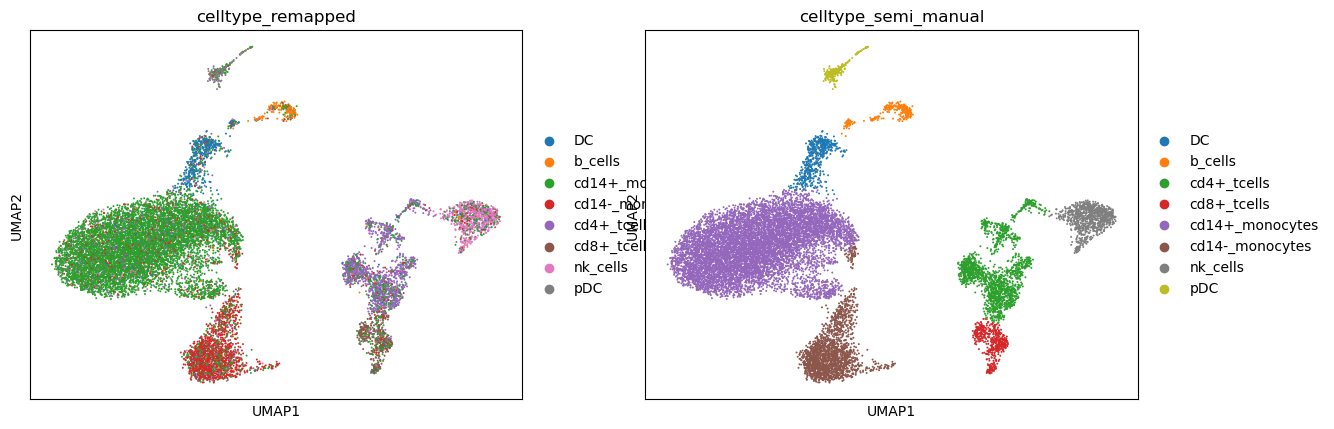

In [ ]:
sc.pl.umap(adata_raw, color = ['celltype_remapped', 'celltype_semi_manual' ])

In [ ]:
cross_tab = pd.crosstab(grn_adata3.obs['celltype_semi_manual'], grn_adata3.obs['leiden_remap'])

In [ ]:
grn_adata3 = add_external_grn(grn_ad=grn_adata3,external_grn=collectri,name_grn='collectri')

In [ ]:
# Identify top targets for each source gene within clusters
# - Keeps up to top_per_source strongest targets
# - Removes regulons smaller than min_reg_size
cluster_column = 'leiden_remap'

min_reg_size = 1
add_neighbourhood_expression_mask(adata_raw, grn_adata3, strict=False, layer = 'counts' )



AnnData object with n_obs × n_vars = 15033 × 132362
    obs: 'Unnamed: 0', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero', 'count_nonzero_norm', 'cd14+_monocytes_nonzero', 'cd14+_monocytes_candidate_edge', 'cd14-_monocytes_nonzero', 'cd14-_monocytes_candidate_edge', 'cd4+_tcells_nonzero', 'cd4+_tcells_candidate_edge', 'nk_cells_nonzero', 'nk_cells_candidate_edge', 'cd8+_tcells_nonzero', 'cd8+_tcells_candidate_e

In [ ]:
for tp in [10, 20, 30, 40, 50]:
    keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=tp, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True)
    all_regulons = make_cluster_regulon_dataframe(keep_edges)
    regus = aggregate_edges(keep_edges, grn_adata3, key='unique')
    all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)
    all_signatures.obs['leiden_remap'] = grn_adata3.obs['leiden_remap'].values

    sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")

    bcrank = sc.get.rank_genes_groups_df(all_signatures, group = 'DC', key  = 'wilcoxon')
    bcrank[['celltype', 'gene']] = bcrank['names'].str.rsplit('_', n=1, expand=True)

    all_regulons  = all_regulons.merge(bcrank, left_on = ['source', 'cluster'], right_on=['gene', 'celltype'])
    all_regulons = all_regulons.to_csv(op.join(analysis_output_dir, f'regulons_{tp}.tsv'), sep = '\t')

Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8+_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC
DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC
Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8+_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC
DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC
Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets

In [ ]:
top_per_source = 30
for tp in [10, 20, 30, 40, 50]:
    keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=tp, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True, tf_column='is_source_collectri')
    all_regulons = make_cluster_regulon_dataframe(keep_edges)
    regus = aggregate_edges(keep_edges, grn_adata3, key='unique')
    all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)
    all_signatures.obs['leiden_remap'] = grn_adata3.obs['leiden_remap'].values

    sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")

    bcrank = sc.get.rank_genes_groups_df(all_signatures, group = 'DC', key  = 'wilcoxon')
    bcrank[['celltype', 'gene']] = bcrank['names'].str.rsplit('_', n=1, expand=True)

    all_regulons = all_regulons.merge(bcrank, left_on = ['source', 'cluster'], right_on=['gene', 'celltype'])

    
    all_regulons.to_csv(op.join(analysis_output_dir, f'regulons_{tp}_TF.tsv'), sep = '\t')

Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8+_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC
DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC
Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8+_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC
DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC
Selecting targets for cluster: DC
Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets

In [ ]:
all_regulons

,source,target,sum_of_edge,cluster,set_type,names,scores,logfoldchanges,pvals,pvals_adj,celltype,gene
0,TCF4,UBE2E2,0.002664,DC,unique,DC_TCF4,16.114952,1.902722,2.003180e-58,8.653736e-58,DC,TCF4
1,FOXP1,SESN3,0.002059,DC,unique,DC_FOXP1,22.353399,1.067026,1.118931e-110,8.631756e-110,DC,FOXP1
2,RUNX2,EPB41,0.003474,DC,unique,DC_RUNX2,20.796684,1.884768,4.637829e-96,2.782698e-95,DC,RUNX2
3,HIVEP2,RUNX1,0.000409,DC,unique,DC_HIVEP2,10.029746,NaN,1.128063e-23,2.900734e-23,DC,HIVEP2
4,EGR1,WDFY2,0.002454,DC,unique,DC_EGR1,3.758231,-0.252090,1.711188e-04,2.566782e-04,DC,EGR1
...,...,...,...,...,...,...,...,...,...,...,...,...
13788,BTG2,DLEU2,0.001878,pDC,all,pDC_BTG2,17.208025,0.769215,2.311814e-66,1.161283e-65,pDC,BTG2
13789,BTG2,LY9,0.001840,pDC,all,pDC_BTG2,17.208025,0.769215,2.311814e-66,1.161283e-65,pDC,BTG2
13790,BTG2,NFKBIA,0.001832,pDC,all,pDC_BTG2,17.208025,0.769215,2.311814e-66,1.161283e-65,pDC,BTG2
13791,BTG2,TAGLN2,0.001749,pDC,all,pDC_BTG2,17.208025,0.769215,2.311814e-66,1.161283e-65,pDC,BTG2


In [ ]:
regus = aggregate_edges(keep_edges, grn_adata3, key='unique')

DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC


In [ ]:
all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)


In [ ]:
all_signatures.obs['leiden_remap'] = grn_adata3.obs['leiden_remap'].values

In [ ]:
# grn_adata3.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_processed.h5ad'))
# all_signatures.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_signatures.h5ad'))

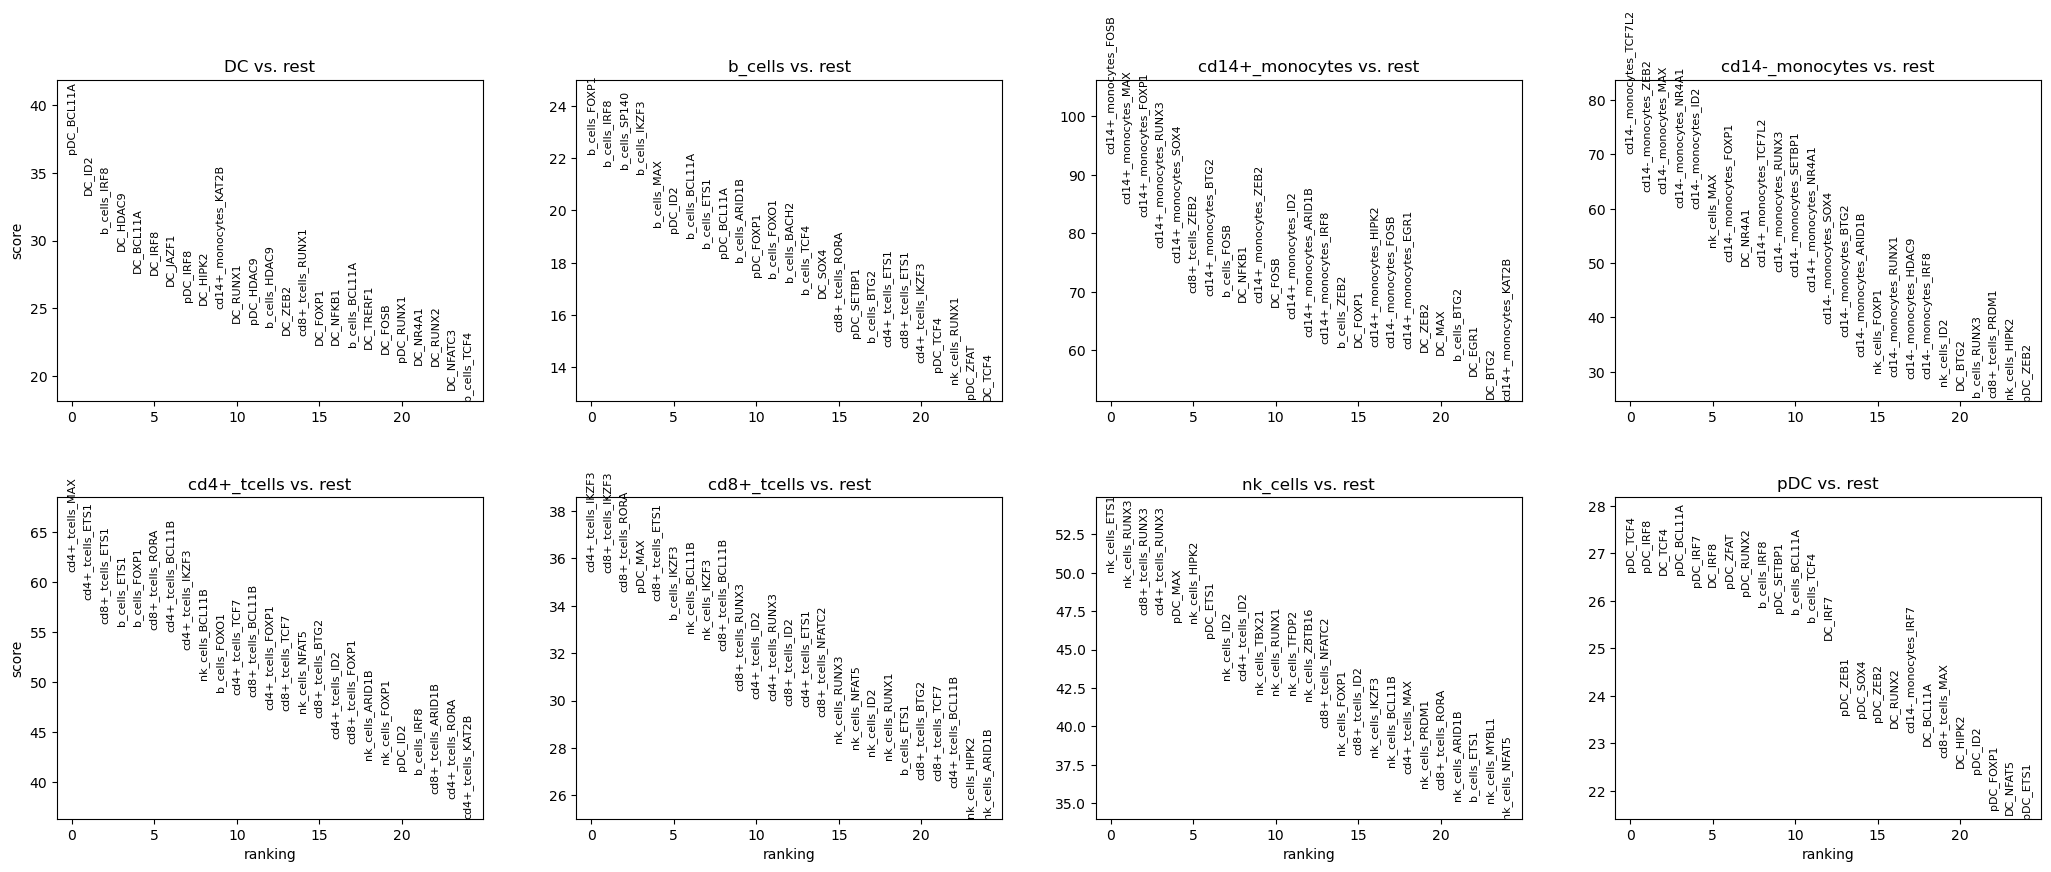

In [ ]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(all_signatures, n_genes=25, sharey=False, key="wilcoxon")

In [1]:
pp = rank_regulon_groups_dotplot(grn_adata3, adata_regl=all_signatures, return_fig=True, new_cluster_column=cluster_column, n_genes=10)

NameError: name 'rank_regulon_groups_dotplot' is not defined

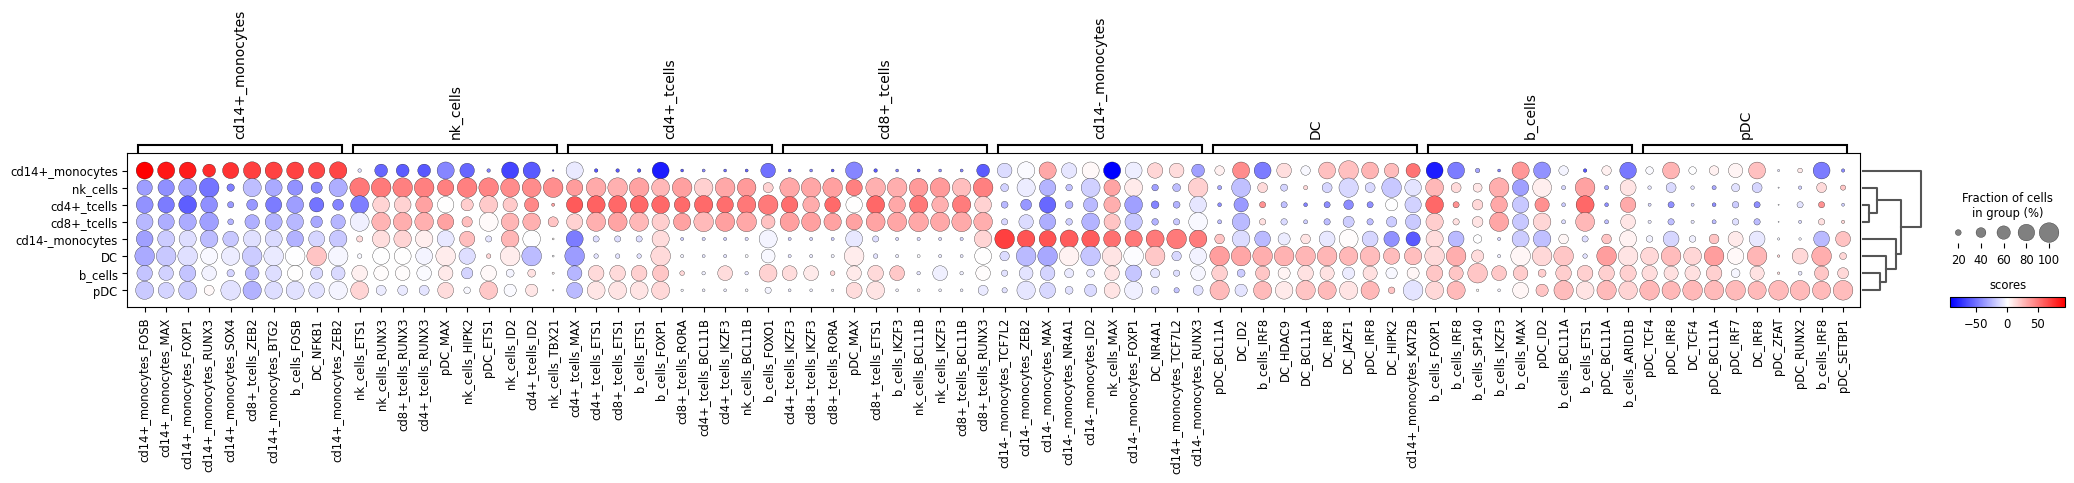

In [ ]:
pp.show()

In [ ]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(adata_raw, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(adata_raw, n_genes=25, sharey=False, key="wilcoxon")

KeyError: 'leiden_remap'

In [ ]:
plot_regulon_comparison(all_signatures, all_regulons, ['0_Camk1d','0_Arhgap15' ])

In [ ]:
bcrank = sc.get.rank_genes_groups_df(all_signatures, group = 'DC', key  = 'wilcoxon')

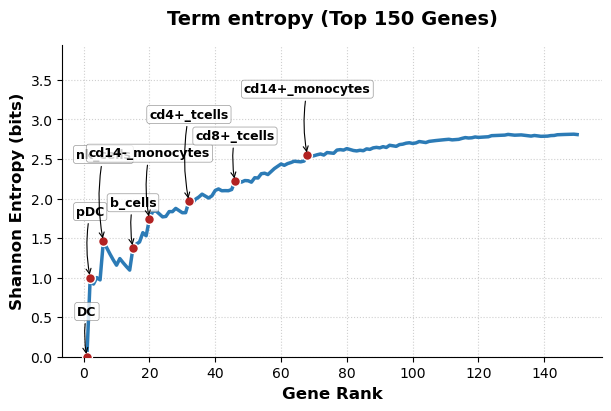

In [ ]:
bcrank_entropy(bcrank, top_n=150, title="Term entropy", figsize=(6,4))